# 04 · Coherent errors: over-rotation and phase error of the 1–2 pulse

A pulse that is meant to rotate by $\pi/2$ about $x$ in the 1–2 subspace actually does $\pi/2 + \epsilon$ about an axis
tilted out of the equator by a phase error $\delta$ (the "heuristic model" of the paper: $H = (\pi/2+\epsilon)\sigma_x + \delta\sigma_z$).
Both errors are tiny per gate and invisible in a Rabi oscillation, so the shop *amplified* them with repeated gates:

* **rotation-error amplification** (Sheldon 2016): |1⟩ → SX12 → (SX12 SX12)$^N$ → measure. Each pair adds $2\epsilon$;
  the population oscillates slowly in $N$ with a period set by $\epsilon$.
* **amplified phase error, APE** (Lucero 2010): |1⟩ → SX12 → (SX12 −SX12)$^n$ → −SX12 at a swept phase → measure. Each pseudo-identity
  leaves $2\delta$ behind; the Ramsey fringe shifts linearly with $n$.

These are the two experiments of the paper's Fig. 1 and Fig. 2. The notebook reproduces their analysis from the saved shots
with `pulseshop.qutrit` (the 3×3 error models) and `pulseshop.readout`, after a look at their 2022–23 ancestors.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, json, glob, os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pulseshop import readout, io, fitting, qutrit
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pi = np.pi

## 1. 2022 — "misrotation" of the 0–1 $\pi/2$ pulse on `ibmq_manila`

The first amplification experiment (`QuantumExperiment/Misrotation`, Sep 2022): $d = 1 … 194$ repeated X01($\pi/2$) pulses, LDA
readout, and a model where every pulse is followed by an extra X01($\epsilon$). The measured curve is kept as a figure; the model
is `qutrit.repeated_halfpi_populations`.

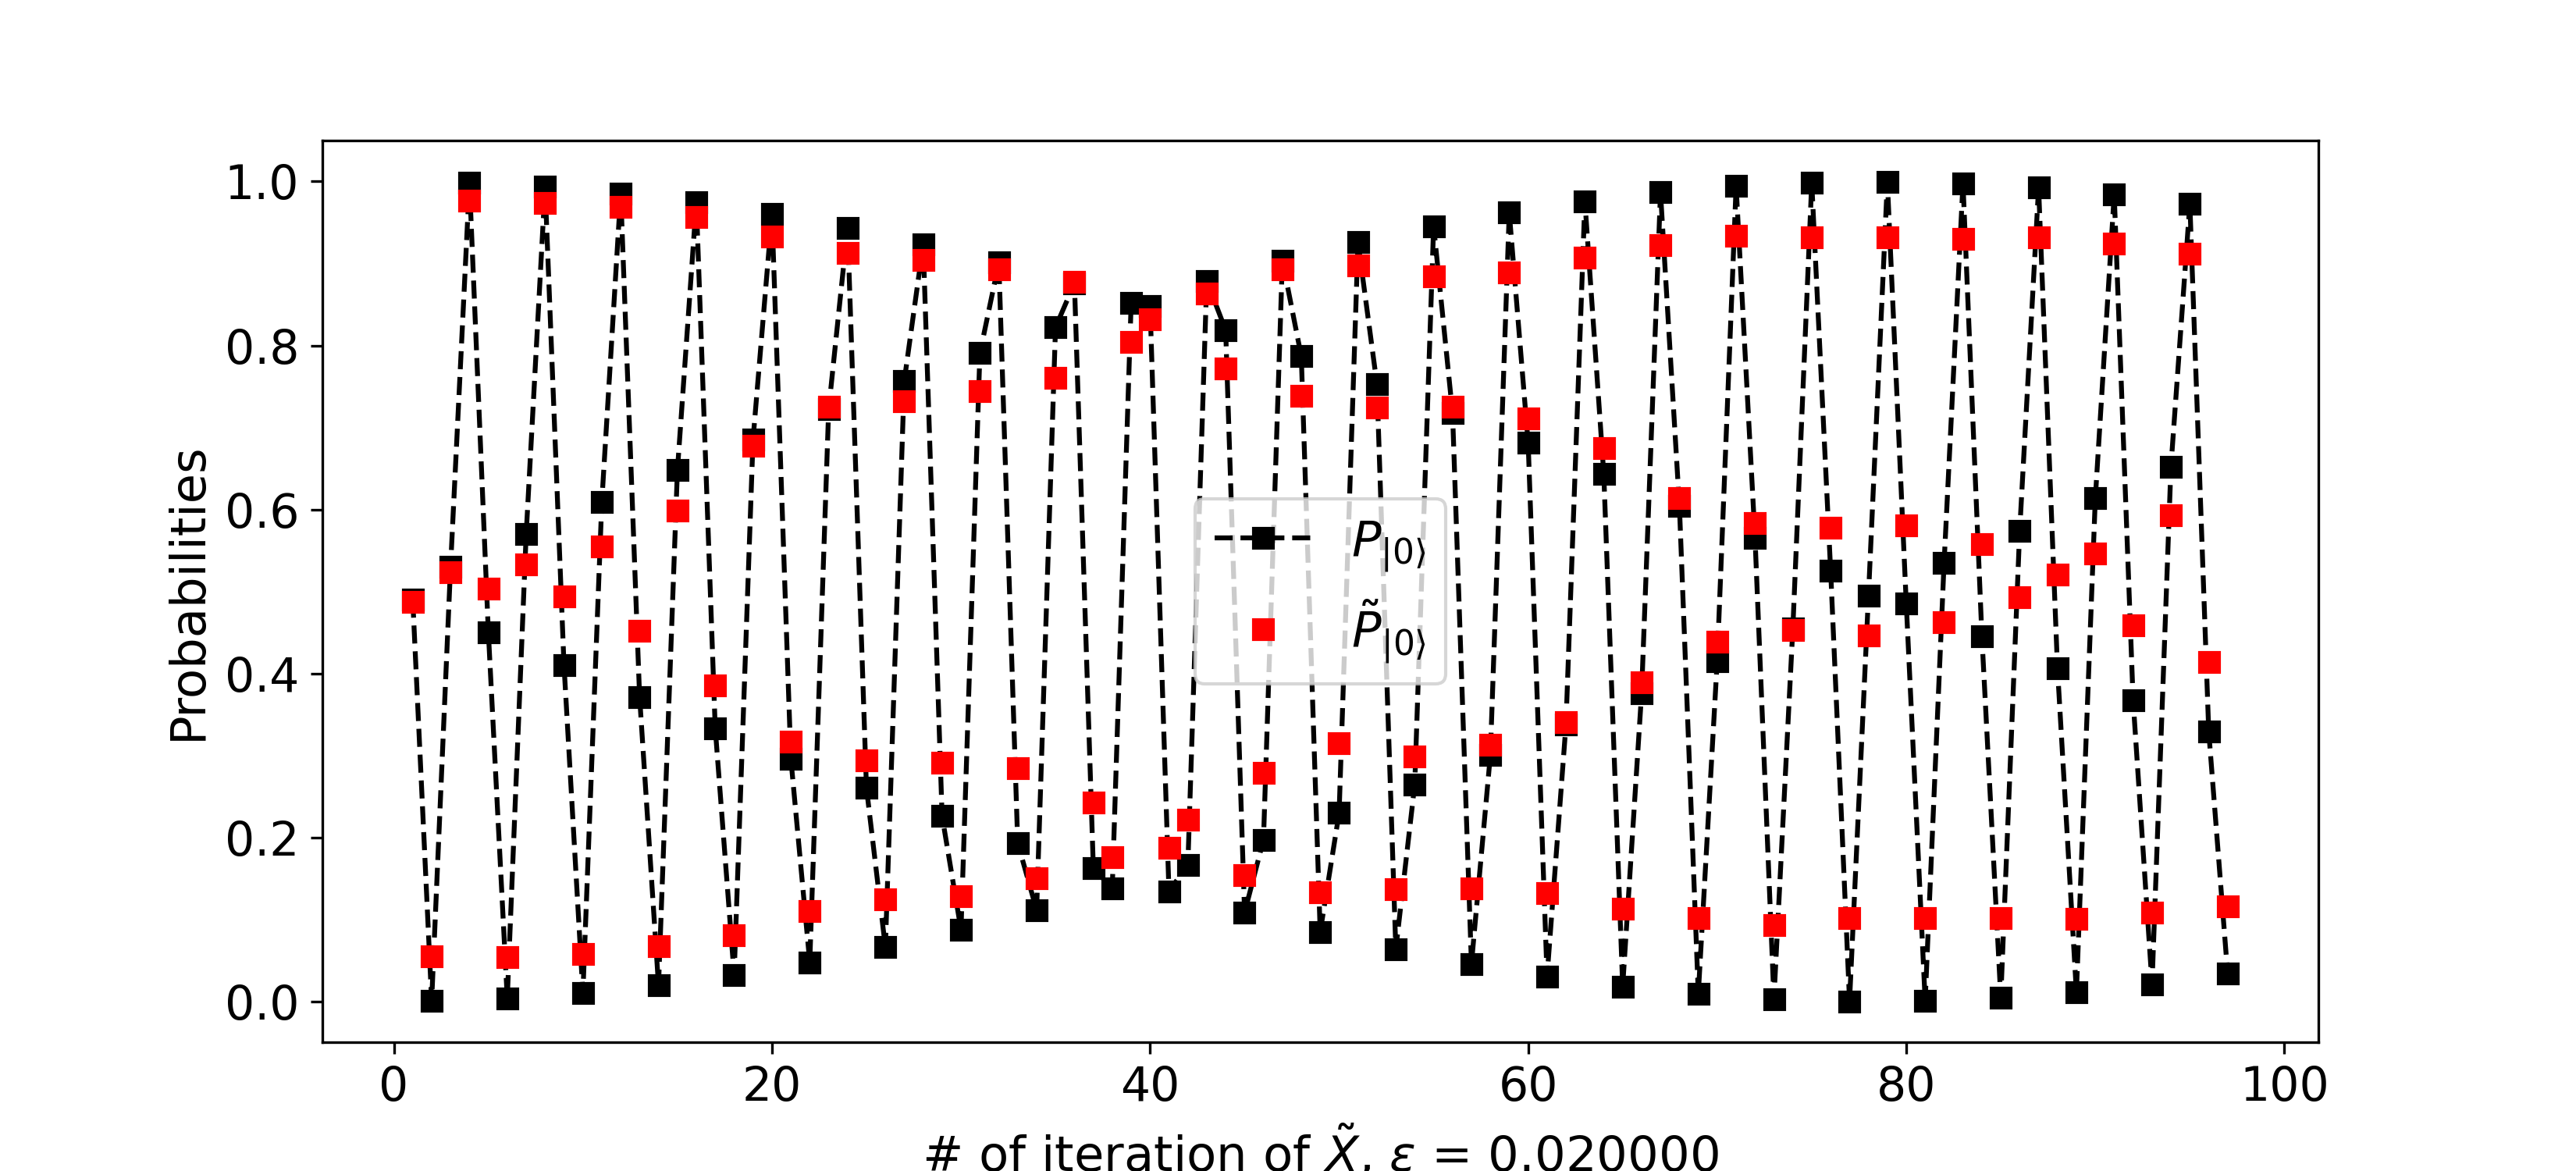

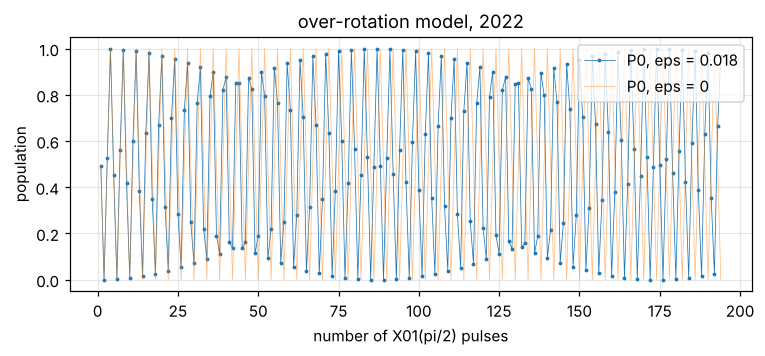

In [2]:
from IPython.display import Image, display
display(Image(filename=str(io.FIG_DIR / "lab_2022/manila_q0_2022-09_misrotation_experiment_vs_model.png"), width=520))
pops = qutrit.repeated_halfpi_populations(pi / 2, 0.018, 194)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.arange(1, 195), pops[:, 0], ".-", ms=3, lw=0.5, label="P0, eps = 0.018")
ax.plot(np.arange(1, 195), qutrit.repeated_halfpi_populations(pi / 2, 0.0, 194)[:, 0], "-", lw=0.5, alpha=0.5, label="P0, eps = 0")
ax.set(xlabel="number of X01(pi/2) pulses", ylabel="population", title="over-rotation model, 2022"); ax.legend()
io.save_fig(fig, "04_misrotation_model_2022")

A 2 % over-rotation turns the 4-periodic pattern of a perfect $\pi/2$ into a slow beat with a period of $2\pi/\epsilon \approx 350$ pulses;
the data of Sep 2022 (ε ≈ 0.018–0.02) show exactly that beat plus decoherence.

## 2. Nov 2023 — fine amplitude of the 1–2 half-$\pi$ pulse (`calibrator/fine_amplitude`)

X01 then $n = 0, 2, …, 22$ repetitions of the 80 dt half-$\pi$ pulse. The note of the day in `param.txt`:
*"Failed since the errors are not amplified quadratically. This means other errors are present"* — the first sign that phase errors,
not amplitude, dominate the 1–2 pulse.

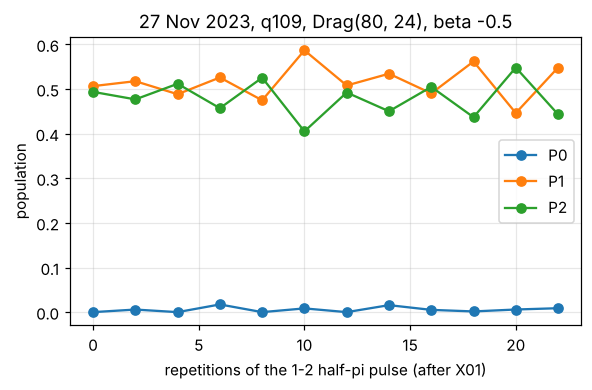

In [3]:
st = [io.load_npy("shop_2023_legacy/calibrator/fine_amplitude/data/27nov", f"state{k}_exp.npy") for k in range(3)]
n = np.arange(0, 24, 2)
fig, ax = plt.subplots(figsize=(6, 3.4))
for k in range(3):
    ax.plot(n, st[k], "o-", label=f"P{k}")
ax.set(xlabel="repetitions of the 1-2 half-pi pulse (after X01)", ylabel="population", title="27 Nov 2023, q109, Drag(80, 24), beta -0.5"); ax.legend()
io.save_fig(fig, "04_fine_amplitude_nov2023")

## 3. Jul 2024 — rotation-error amplification, before and after DRAG (120 → 48 dt pulses)

`calibrator/rotation_error/qubit109/main.ipynb`: X, SX12, then $N$ further SX12 pulses ($N = 0, 2, …, 40$ — single pulses in this 2024
version, pairs in the 2025 one), X, measure. The first three circuits of each file are the calibration circuits. Rounds 10–11 (11/16 Jul)
are before, rounds 12–15 (17 Jul) after the DRAG correction of notebook 03. Because every step adds a full $\pi$ about a slightly tilted axis,
the populations alternate between two latitudes that drift with $N$; the drift is what carries $\epsilon$ and $\delta$.

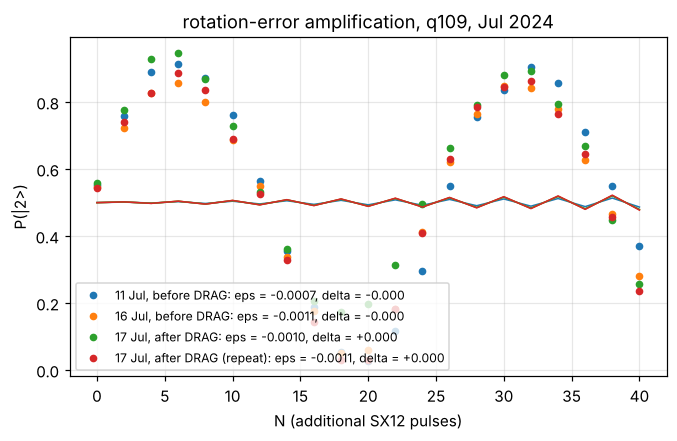

In [4]:
N_list = 2 * np.arange(21)

def rotation_run_2024(name):
    iq = io.load_npy("shop_2024/calibrator/rotation_error/qubit109/data/dur48", name + ".npy")
    da = readout.DataAnalysis(iq)
    return da.run(), da

def fit_heuristic(N_list, p2_exp, mode="pairs"):
    """Grid search + Nelder-Mead fit of (epsilon, delta) of qutrit.rot_x12 to the measured P2(N)."""
    def obj(x):
        sim = qutrit.rotation_error_sequence(x[0], x[1], N_list, mode)[:, 1]
        return np.mean((sim - p2_exp) ** 2)
    A = np.linspace(-0.15, 0.15, 31); P = np.linspace(-0.6, 0.6, 31)
    grid = np.array([[obj((a, q)) for q in P] for a in A])
    i, j = np.unravel_index(np.argmin(grid), grid.shape)
    res = minimize(obj, (A[i], P[j]), method="Nelder-Mead", options={"xatol": 1e-6, "fatol": 1e-10, "maxiter": 2000})
    res.mse_ideal = obj((0.0, 0.0))
    return res

fig, ax = plt.subplots(figsize=(7, 4))
for name, lab, c in [("round10_11jul24", "11 Jul, before DRAG", "C0"), ("round11_16jul24", "16 Jul, before DRAG", "C1"), ("round13_17jul24_afterDRAG", "17 Jul, after DRAG", "C2"), ("round15_17jul24_afterDRAG", "17 Jul, after DRAG (repeat)", "C3")]:
    pops, da = rotation_run_2024(name)
    # with the final X the measured P1 (after X) corresponds to the population that was in |2>?  No: the X swaps |0><->|1|; |2> is untouched.
    p2 = pops[:, 2]
    res = fit_heuristic(N_list, p2, mode="single")
    ax.plot(N_list, p2, "o", color=c, ms=4, label=f"{lab}: eps = {res.x[0]:+.4f}, delta = {res.x[1]:+.3f}")
    ax.plot(N_list, qutrit.rotation_error_sequence(res.x[0], res.x[1], N_list, "single")[:, 1], "-", color=c, lw=1)
ax.set(xlabel="N (additional SX12 pulses)", ylabel="P(|2>)", title="rotation-error amplification, q109, Jul 2024")
ax.legend(fontsize=8)
io.save_fig(fig, "04_rotation_error_jul2024")

Two points of this plot became the backbone of the paper: (i) the envelope of the alternation is *not* explained by an over-rotation
alone — pure $\epsilon$ keeps the state on the equator ($P_2 = 1/2$ for every $N$) — hence the phase term $\delta \approx 0.3$–$0.5$ rad;
(ii) after the DRAG correction the picture barely changes at this pulse length, which is what pushed the shop to the 40 dt pulse and
the pair sequence below, where $\delta$ shows up as a slow, clean oscillation.

## 4. Sep 2024 – Jan 2025 — the paper's Fig. 1 (20 ns pulse)

`calibrator/rotation/rotation_script.ipynb` repeated the experiment on the 40 dt pulse with 5 000–10 000 shots per point and the radius
discriminator (notebook 02). The runs kept in `data/pending_2025/calibrator/rotation`:

In [5]:
rd = io.load_json("pending_2025", "rabi_discrim.json")
radius = readout.RadiusDiscriminator(complex(rd["cluster_0_mean"]["re"], rd["cluster_0_mean"]["im"]), complex(rd["cluster_2_mean"]["re"], rd["cluster_2_mean"]["im"]), rd["radius_fit"])
runs = {
    "cw0s2fsrxqkg008e2cag": "uncorrected (amp 0.25136, no DRAG)",
    "cw0w06rvka8g008b997g": "DRAG-Y only (amp 0.25136, beta -0.414)",
    "cw0wed14v2e0008sg2gg": "DRAG + scaled amp 0.23630 (run 1)",
    "cw13qsqvka8g008b9vg0": "DRAG + scaled amp 0.23630 (run 2)",
    "cw24b0crxqkg008e56j0": "DRAG + scaled amp 0.23630 (run 3, 10k shots)",
    "cvr07a5zrwzg008axdc0": "scaled amp, no DRAG (Sep 2024)",
}
results = {}
for job, lab in runs.items():
    iq, prm = io.load_job(f"pending_2025/calibrator/rotation/data/{job}")
    pops = readout.count(iq, radius)
    N = 2 * np.arange(prm["N0"])
    res = fit_heuristic(N, pops[:, 2])
    results[job] = (N, pops, res, prm)
    print(f"{job} {prm['datetime'][:10]} {lab:42s} eps = {res.x[0]:+.4f} ({100*res.x[0]/(pi/2):+.1f} % of pi/2)  delta = {res.x[1]:+.4f}  mse {res.fun:.1e} (ideal pulse: {res.mse_ideal:.1e})")

cw0s2fsrxqkg008e2cag 2024-10-05 uncorrected (amp 0.25136, no DRAG)         eps = +0.0406 (+2.6 % of pi/2)  delta = +0.4441  mse 8.9e-05 (ideal pulse: 1.0e-01)


cw0w06rvka8g008b997g 2024-10-06 DRAG-Y only (amp 0.25136, beta -0.414)     eps = +0.0503 (+3.2 % of pi/2)  delta = -0.4057  mse 1.2e-04 (ideal pulse: 1.1e-01)


cw0wed14v2e0008sg2gg 2024-10-06 DRAG + scaled amp 0.23630 (run 1)          eps = -0.0662 (-4.2 % of pi/2)  delta = -0.4554  mse 5.3e-05 (ideal pulse: 6.0e-04)


cw13qsqvka8g008b9vg0 2024-10-06 DRAG + scaled amp 0.23630 (run 2)          eps = -0.0719 (-4.6 % of pi/2)  delta = -0.4757  mse 6.6e-05 (ideal pulse: 6.1e-04)


cw24b0crxqkg008e56j0 2024-10-07 DRAG + scaled amp 0.23630 (run 3, 10k shots) eps = -0.0722 (-4.6 % of pi/2)  delta = -0.4713  mse 7.1e-05 (ideal pulse: 1.8e-03)


cvr07a5zrwzg008axdc0 2024-09-22 scaled amp, no DRAG (Sep 2024)             eps = -0.0483 (-3.1 % of pi/2)  delta = -0.4355  mse 7.3e-05 (ideal pulse: 4.8e-02)


For the uncorrected pulse the fit gives $\epsilon/(\pi/2) \approx 2.6$ %, the number the story notebook quotes for the heuristic model
(2.7 %; the master-equation model of notebook 10 gives 3.7 %, "a difference to settle"). For the corrected pulses the curve is flat at
0.47 and the two-parameter fit lands in a valley of the model where $\epsilon$ and $\delta$ compensate each other over 40 pairs; the ideal pulse
$(0, 0)$ reproduces the same data to an rms of 0.025, which is just the readout bias of the |2⟩ assignment. The honest statement is
therefore that after both corrections $\epsilon$ and $\delta$ are below what this sequence can resolve. (`paper/plot.ipynb` lists $(0.078, 0.274)$ and $(0.089, 0.196)$ for panels (a) and (b); it used a
slightly different outlier rule in the discriminator and its own starting guesses, and the valley of this fit is shallow in the $\epsilon$ direction.)
Fig. 1 of the paper:

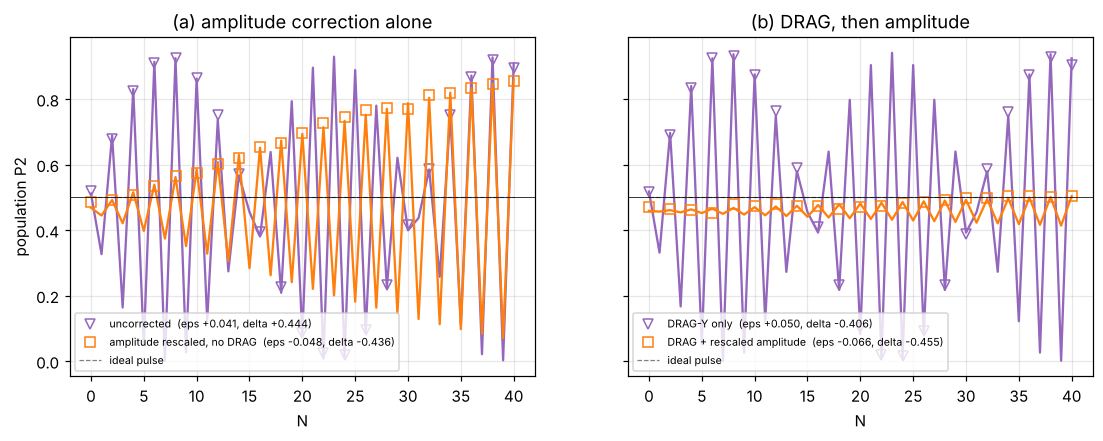

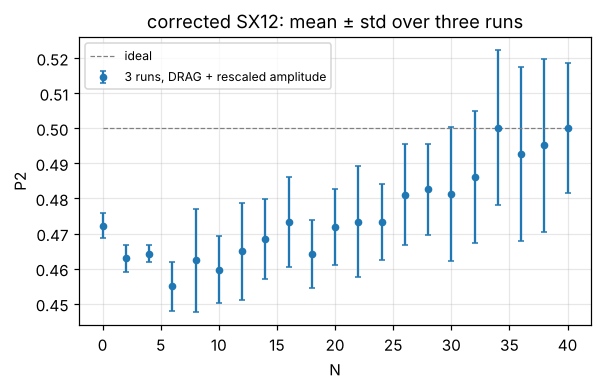

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
Nd = np.arange(0, 41)
for ax, pair, title in [(axes[0], [("cw0s2fsrxqkg008e2cag", "C4", "v", "uncorrected"), ("cvr07a5zrwzg008axdc0", "C1", "s", "amplitude rescaled, no DRAG")], "(a) amplitude correction alone"),
                        (axes[1], [("cw0w06rvka8g008b997g", "C4", "v", "DRAG-Y only"), ("cw0wed14v2e0008sg2gg", "C1", "s", "DRAG + rescaled amplitude")], "(b) DRAG, then amplitude")]:
    for job, c, m, lab in pair:
        N, pops, res, prm = results[job]
        ax.plot(N, pops[:, 2], m, color=c, mfc="none", ms=6, label=f"{lab}  (eps {res.x[0]:+.3f}, delta {res.x[1]:+.3f})")
        ax.plot(Nd, qutrit.rotation_error_sequence(res.x[0], res.x[1], Nd)[:, 1], "-", color=c, lw=1.5)
    ax.plot(Nd, qutrit.rotation_error_sequence(0.0, 0.0, Nd)[:, 1], "--", color="grey", lw=0.8, label="ideal pulse")
    ax.axhline(0.5, color="k", lw=0.5)
    ax.set(xlabel="N", title=title); ax.legend(fontsize=7, loc="lower left")
axes[0].set_ylabel("population P2")
io.save_fig(fig, "04_fig1_rotation_error_paper")

# repeatability of the corrected pulse
fig, ax = plt.subplots(figsize=(6, 3.4))
stack = np.array([results[j][1][:, 2] for j in ["cw0wed14v2e0008sg2gg", "cw13qsqvka8g008b9vg0", "cw24b0crxqkg008e56j0"]])
ax.errorbar(results["cw0wed14v2e0008sg2gg"][0], stack.mean(axis=0), yerr=stack.std(axis=0), fmt="o", ms=4, capsize=2, label="3 runs, DRAG + rescaled amplitude")
ax.plot(Nd, qutrit.rotation_error_sequence(0.0, 0.0, Nd)[:, 1], "--", color="grey", lw=0.8, label="ideal")
ax.set(xlabel="N", ylabel="P2", title="corrected SX12: mean ± std over three runs"); ax.legend(fontsize=8)
io.save_fig(fig, "04_fig1b_repeats")

With both corrections the curve stays at 0.47 ± 0.02 out to 40 pairs (80 gates): whatever $\epsilon$ and $\delta$ remain, they no longer
move the population over 80 gates, and the two-parameter fit cannot pin them (see above). Notebook 10 fits the same curves with a Lindblad pulse-train simulation (the "master equation"
model of `story.ipynb`, $\epsilon/(\pi/2) \approx 3.7$ % for the uncorrected pulse against 2.7 % from this heuristic — the discrepancy the story notebook set out to settle).

## 5. Oct 2024 — amplified phase error, the paper's Fig. 2

`characterization/ape/ape.ipynb` ran X, SX12, $n$ × (SX12, −SX12), −SX12 at 75 phases, X, measure for $n = 1, 3$ and $5, 7$, without
(`cw0sjvk…`, `cw0t1qe…`) and with (`cw0twsk…`, `cw0v840…`) the DRAG correction. The final X maps |1⟩ → |0⟩, so the fringe of interest is $P_0$.

{'without DRAG': np.float64(0.04406), 'with DRAG': np.float64(0.0003)}  (paper: 4.40e-2 before, 8.27e-4 after)


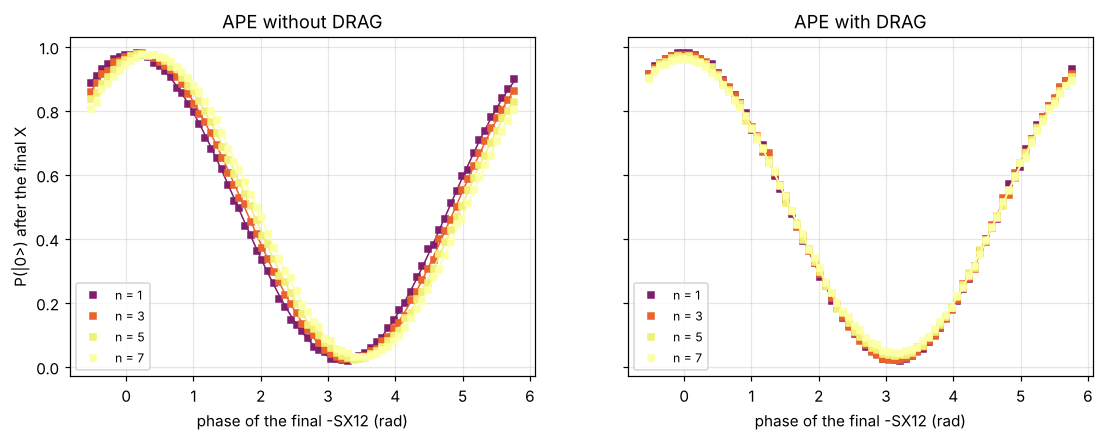

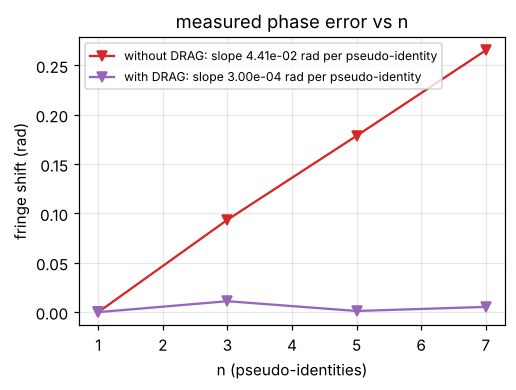

In [7]:
ape_jobs = {"cw0sjvk79ws0008z27j0": ("without DRAG", [1, 3]), "cw0t1qe4v2e0008sfxeg": ("without DRAG", [5, 7]),
            "cw0twskjz3x0008j6xx0": ("with DRAG", [1, 3]), "cw0v84079ws0008z2as0": ("with DRAG", [5, 7])}
angles = np.linspace(-pi / 6, -pi / 6 + 2 * pi, 75)
fringes = {"without DRAG": {}, "with DRAG": {}}
for job, (kind, reps) in ape_jobs.items():
    iq, prm = io.load_job(f"pending_2025/characterization/ape/data/{job}")
    pops = readout.count(iq, radius)
    p0 = pops[:, 0].reshape(len(reps), 75)
    for k, n in enumerate(reps):
        fringes[kind][n] = p0[k]

def fringe_phase(angles, y):
    pars, yfit, _ = fitting.fit_function(angles, y, fitting.cosine, [(y.max() - y.min()) / 2, y.mean(), 2 * pi, angles[np.argmax(y)]])
    return pars, yfit

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
slopes = {}
for ax, kind in zip(axes, ["without DRAG", "with DRAG"]):
    phases = []
    for n, y in sorted(fringes[kind].items()):
        pars, yfit = fringe_phase(angles, y)
        phases.append((n, pars[3] % (2 * pi)))
        ax.plot(angles, y, "s", ms=4, color=plt.cm.inferno(0.2 + 0.15 * n), label=f"n = {n}")
        ax.plot(angles, yfit, "-", color=plt.cm.inferno(0.2 + 0.15 * n), lw=1)
    ax.set(xlabel="phase of the final -SX12 (rad)", title=f"APE {kind}"); ax.legend(fontsize=8)
    ns = np.array([p[0] for p in phases]); ph = np.unwrap(np.array([p[1] for p in phases]))
    m, c = np.polyfit(ns, ph - ph[0], 1)
    slopes[kind] = (ns, ph - ph[0], m)
axes[0].set_ylabel("P(|0>) after the final X")
io.save_fig(fig, "04_fig2_ape_fringes")

fig, ax = plt.subplots(figsize=(5, 3.4))
for kind, c in [("without DRAG", "C3"), ("with DRAG", "C4")]:
    ns, dph, m = slopes[kind]
    ax.plot(ns, dph, "v-", color=c, label=f"{kind}: slope {m:.2e} rad per pseudo-identity")
ax.set(xlabel="n (pseudo-identities)", ylabel="fringe shift (rad)", title="measured phase error vs n"); ax.legend(fontsize=8)
io.save_fig(fig, "04_fig2_inset_phase_error_slope")
print({k: round(v[2], 5) for k, v in slopes.items()}, " (paper: 4.40e-2 before, 8.27e-4 after)")

Each pseudo-identity leaves $2\delta$ of phase behind: without DRAG the fringe walks by ≈ 4 × 10⁻² rad per pseudo-identity, with DRAG by
< 10⁻³ — the phase error of the 20 ns pulse is suppressed by two orders of magnitude (the paper's figure, 4.40e-2 → 8.27e-4, is a factor fifty). The two-parameter model fit of the same fringes
(`qutrit.ape_sequence`, used in `paper/plot.ipynb` to cross-check $\delta$) is left as an exercise; its result was $\delta = 0.046 \pm 0.003$ before correction.

## 6. What the error budget looks like after this notebook

| error of the 20 ns SX12 | before | after | fixed by |
|---|---|---|---|
| over-rotation $\epsilon$ | 2.6–3.7 % of $\pi/2$ (heuristic / master equation) | not resolvable over 40 pairs | amplitude rescaling from the rotation-error fit |
| phase error, APE slope | 4.4 × 10⁻² rad per pseudo-identity (the heuristic fit's $\delta \approx 0.4$ is the axis tilt of a different model) | 3 × 10⁻⁴ | DRAG $\beta = -0.41$ (DRAPE, notebook 03) |
| leakage to |3⟩ | not measured | — | pulse shaping, notebook 10 |
| frame phase between subspaces | — | — | tracked, not removed: notebooks 07–08 |